# 01 — EDA: Raw Transaction Data

UCI Online Retail II — a UK-based online retailer's transactional records (2009-12-01 → 2011-12-09, ~1M line items). One row per invoice line. No churn label; this notebook explores structure and quality only.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_SEED = 42
DATA_DIR = Path('..') / 'data' / 'raw'

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 1. Load Data

In [124]:
df = pd.read_csv(
    DATA_DIR / 'online_retail_II.csv',
    dtype={'Customer ID': 'Int64'},
    parse_dates=['InvoiceDate'],
    encoding='ISO-8859-1',
)

df = df.rename(columns={
    'Invoice': 'invoice',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'Price': 'price',
    'Customer ID': 'customer_id',
    'Country': 'country',
})

print(df.shape)
df.head(5)

(1067371, 8)


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [97]:
print(f'Rows                : {len(df):,}')
print(f'Unique invoices     : {df["invoice"].nunique():,}')
print(f'Unique stock codes  : {df["stock_code"].nunique():,}')
print(f'Unique customers    : {df["customer_id"].nunique():,} (excluding nulls)')
print(f'Unique countries    : {df["country"].nunique()}')
print(f'Invoice date range  : {df["invoice_date"].min()} → {df["invoice_date"].max()}')


Rows                : 1,067,371
Unique invoices     : 53,628
Unique stock codes  : 5,305
Unique customers    : 5,942 (excluding nulls)
Unique countries    : 43
Invoice date range  : 2009-12-01 07:45:00 → 2011-12-09 12:50:00


## 2. Schema & Data Types

In [98]:
# Ger number of entries, N of non-null values and variable types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   price         1067371 non-null  float64       
 6   customer_id   824364 non-null   Int64         
 7   country       1067371 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 66.2+ MB


## 3. Missing Values

In [99]:
missing_pct = df.isnull().mean() * 100
print('Percentage of missing values by variable:')
missing_pct.round(3)

Percentage of missing values by variable:


invoice         0.00
stock_code      0.00
description     0.41
quantity        0.00
invoice_date    0.00
price           0.00
customer_id    22.77
country         0.00
dtype: float64

## 4. Data Quality Checks

Things to verify on a raw transactional dump:
- Cancellations (invoices prefixed with `C`) and how they correlate with negative quantities.
- For returns (negative quantity), whether `price` is also signed negative or stays positive.
- Non-positive prices (data errors, adjustments).
- Exact duplicate rows.
- Rows with missing `customer_id` (cannot be attributed to a customer).


**Quick quality flags.** A first pass over the obvious failure modes in one place: how many rows are cancellations (C-prefix), have negative or zero quantity, negative or zero price, a missing `customer_id`, or are exact duplicates. The crosstab then shows how the cancellation flag lines up with negative quantity, and the final block checks whether negative-quantity (return) rows keep a positive `price` or carry a signed-negative one.

In [100]:
is_cancellation = df['invoice'].astype(str).str.startswith('C')
neg_qty          = (df['quantity'] < 0)
zero_qty         = (df['quantity'] == 0)
neg_price        = (df['price'] < 0)
zero_price       = (df['price'] == 0)
missing_customer = df['customer_id'].isna()
duplicates       = df.duplicated()

print(f'Cancellation invoices (C-prefix)   : {is_cancellation.sum():>8,} ({is_cancellation.mean()*100:.2f}%)')
print(f'Rows with quantity < 0             : {neg_qty.sum():>8,}')
print(f'Rows with quantity == 0            : {zero_qty.sum():>8,}')
print(f'Rows with price < 0                : {neg_price.sum():>8,}')
print(f'Rows with price == 0               : {zero_price.sum():>8,}')
print(f'Rows with missing customer_id      : {missing_customer.sum():>8,} ({missing_customer.mean()*100:.2f}%)')
print(f'Exact duplicate rows               : {duplicates.sum():>8,} ({duplicates.mean()*100:.2f}%)')

print()
print('Overlap: cancellation flag vs negative quantity')
print(pd.crosstab(is_cancellation, neg_qty, rownames=['is_cancellation'], colnames=['quantity<0']))

print()
print('For rows with negative quantity (returns), is price also negative?')
ret = df[neg_qty]
print(f'  Rows with quantity < 0      : {len(ret):,}')
print(f'    price > 0                 : {(ret["price"] > 0).sum():,}')
print(f'    price == 0                : {(ret["price"] == 0).sum():,}')
print(f'    price < 0                 : {(ret["price"] < 0).sum():,}')
print()
print('Price summary on negative-quantity rows:')
print(ret['price'].describe().round(2))

Cancellation invoices (C-prefix)   :   19,494 (1.83%)
Rows with quantity < 0             :   22,950
Rows with quantity == 0            :        0
Rows with price < 0                :        5
Rows with price == 0               :    6,202
Rows with missing customer_id      :  243,007 (22.77%)
Exact duplicate rows               :   34,335 (3.22%)

Overlap: cancellation flag vs negative quantity
quantity<0         False  True 
is_cancellation                
False            1044420   3457
True                   1  19493

For rows with negative quantity (returns), is price also negative?
  Rows with quantity < 0      : 22,950
    price > 0                 : 19,493
    price == 0                : 3,457
    price < 0                 : 0

Price summary on negative-quantity rows:
count   22,950.00
mean        38.10
std        549.83
min          0.00
25%          0.85
50%          2.25
75%          4.95
max     38,970.00
Name: price, dtype: float64


**One stock code → many descriptions?** Count how many distinct (normalised) descriptions each `stock_code` carries. Codes with more than one description signal inconsistent or dirty product labelling.

In [101]:
desc_norm = df['description'].astype(str).str.strip().str.upper()

code_description = (
    df.assign(description_norm=desc_norm)
      .groupby('stock_code')['description_norm']
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name='unique_descriptions')
)

n_codes    = len(code_description)
n_multi    = (code_description['unique_descriptions'] > 1).sum()
n_nan_desc = df[df['description'].isna()]['stock_code'].nunique()

print(f'Stock codes total                       : {n_codes:,}')
print(f'Stock codes with >1 description         : {n_multi:,} ({n_multi/n_codes*100:.2f}%)')
print(f'Stock codes with any NaN description    : {n_nan_desc:,}')

code_description[code_description['unique_descriptions'] > 1]


Stock codes total                       : 5,305
Stock codes with >1 description         : 2,832 (53.38%)
Stock codes with any NaN description    : 2,451


,stock_code,unique_descriptions
0,20713,9
1,21181,8
2,22423,8
3,23084,8
4,22734,8
...,...,...
2827,21587,2
2828,16162L,2
2829,16161U,2
2830,22300,2


In [126]:
# Check a couple of examples with the stock_ids that have multiple descriptions
for i in ('20713', '21181', '22423', '23084'):
    print(f'Number of unique descriptions for {i}: \n {df[df['stock_code'] == i]['description'].unique()}')

Number of unique descriptions for 20713: 
 ['JUMBO BAG OWLS' 'missing' nan 'wrongly marked. 23343 in box'
 'wrongly coded-23343' 'found' 'Found' 'wrongly marked 23343'
 'Marked as 23343' 'wrongly coded 23343']
Number of unique descriptions for 21181: 
 ['PLEASE ONE PERSON  METAL SIGN' 'PLEASE ONE PERSON METAL SIGN' 'missing'
 nan 'on cargo order' 'adjustment' 'check' 'dotcom']
Number of unique descriptions for 22423: 
 ['REGENCY CAKESTAND 3 TIER' 'smashed' 'damaged' nan
 'broken, uneven bottom' 'wonky bottom/broken' 'faulty' 'damages']
Number of unique descriptions for 23084: 
 ['RABBIT NIGHT LIGHT' nan 'temp adjustment'
 'allocate stock for dotcom orders ta'
 'add stock to allocate online orders' 'for online retail orders' 'Amazon'
 'website fixed']


**One description → many stock codes?** The reverse view: how many distinct `stock_code`s share the same (normalised) description. Generic descriptions such as `CHECK`, `DAMAGED` or `?` map to many codes and flag non-product / adjustment rows.

In [105]:
mask = df['description'].notna()

description_codes = (
    df[mask]
      .assign(description_norm=desc_norm[mask])
      .groupby('description_norm')['stock_code']
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name='unique_stock_codes')
)

n_desc  = len(description_codes)
n_multi = (description_codes['unique_stock_codes'] > 1).sum()

print(f'Distinct descriptions                   : {n_desc:,}')
print(f'Descriptions mapped to >1 stock_code    : {n_multi:,} ({n_multi/n_desc*100:.2f}%)')

description_codes[description_codes['unique_stock_codes'] > 1].head(20)


Distinct descriptions                   : 5,631
Descriptions mapped to >1 stock_code    : 293 (5.20%)


,description_norm,unique_stock_codes
0,CHECK,149
1,DAMAGED,94
2,?,88
3,DAMAGES,84
4,FOUND,37
5,MISSING,29
6,SOLD AS SET ON DOTCOM,20
7,ADJUSTMENT,17
8,AMAZON,15
9,DOTCOM,15


**Stock code format composition.** Break unique `stock_code`s down by character makeup (numbers only, letters only, mixed alphanumeric, other) to understand the coding scheme and spot non-standard codes (e.g. `POST`, `BANK CHARGES`, `gift_0001_*`).

In [106]:
# stock_code format breakdown by character composition (unique values only).
unique_codes = pd.Series(df['stock_code'].astype(str).unique())

is_alpha_only   = unique_codes.str.fullmatch(r'[A-Za-z]+')
is_numeric_only = unique_codes.str.fullmatch(r'[0-9]+')
is_alnum_mixed  = unique_codes.str.fullmatch(r'(?=.*[A-Za-z])(?=.*[0-9])[A-Za-z0-9]+')
is_other        = ~(is_alpha_only | is_numeric_only | is_alnum_mixed)

n = len(unique_codes)
print(f'Unique stock codes                  : {n:,}')
print(f'  Numbers only                      : {is_numeric_only.sum():>6,} ({is_numeric_only.mean()*100:.2f}%)')
print(f'  Letters only                      : {is_alpha_only.sum():>6,} ({is_alpha_only.mean()*100:.2f}%)')
print(f'  Letters + numbers (mixed alnum)   : {is_alnum_mixed.sum():>6,} ({is_alnum_mixed.mean()*100:.2f}%)')
print(f'  Other (contains symbols/punct.)   : {is_other.sum():>6,} ({is_other.mean()*100:.2f}%)')
print()
print('Samples — numbers only      :', unique_codes[is_numeric_only].head(10).tolist())
print('Samples — letters only      :', unique_codes[is_alpha_only].head(10).tolist())
print('Samples — letters + numbers :', unique_codes[is_alnum_mixed].head(10).tolist())
print('Samples — other             :', unique_codes[is_other].head(10).tolist())


Unique stock codes                  : 5,305
  Numbers only                      :  3,590 (67.67%)
  Letters only                      :     16 (0.30%)
  Letters + numbers (mixed alnum)   :  1,688 (31.82%)
  Other (contains symbols/punct.)   :     11 (0.21%)

Samples — numbers only      : ['85048', '22041', '21232', '22064', '21871', '21523', '22350', '22349', '22195', '22353']
Samples — letters only      : ['POST', 'D', 'DOT', 'M', 'PADS', 'ADJUST', 'DCGSSGIRL', 'GIFT', 'DCGSLBOY', 'm']
Samples — letters + numbers : ['79323P', '79323W', '48173C', '35004B', '84596F', '84596L', '84507B', '84970S', '84031A', '84031B']
Samples — other             : ['BANK CHARGES', 'gift_0001_80', 'gift_0001_20', 'gift_0001_10', 'gift_0001_50', 'gift_0001_30', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70', 'gift_0001_90']


**Example.** Inspect a few mixed-alphanumeric codes to see what the trailing letter encodes (e.g. `84031A`/`84031B`, `48173C`/`48173A`).

In [107]:
# Check examples for letters + numbers
stock_code_test1 = '84031A'
stock_code_test2 = '84031B'
print(f'Check the results for {stock_code_test1} and {stock_code_test2}')
print(df[(df['stock_code'] == stock_code_test1) |
         (df['stock_code'] == stock_code_test2)][['stock_code', 'description']].drop_duplicates())

print('\n')

stock_code_test3 = '48173C'
stock_code_test4 = '48173A'
print(f'Check the results for {stock_code_test3} and {stock_code_test4}')
print(df[(df['stock_code'] == stock_code_test3) |
         (df['stock_code'] == stock_code_test4)][['stock_code', 'description']].drop_duplicates())

Check the results for 84031A and 84031B
   stock_code                          description
61     84031A   CHARLIE+LOLA RED HOT WATER BOTTLE 
62     84031B  CHARLIE LOLA BLUE HOT WATER BOTTLE 


Check the results for 48173C and 48173A
       stock_code            description
12         48173C  DOOR MAT BLACK FLOCK 
39399      48173C                    MIA
71015      48173A    DOOR MAT BLUE FLOCK
80383      48173A                    NaN
252995     48173C   DOORMAT BLACK FLOCK 
415700     48173C                damaged
869460     48173C                    NaN


The cases when the stock_code has same number but different letts is mostly because of a feature that is different in the product (e.g., color).

**Invoice format composition.** The same character-makeup breakdown for `invoice` values, confirming invoices are numeric except for the `C`-prefixed cancellations (which show up as mixed alphanumeric).

In [108]:
# invoice format breakdown by character composition (unique values only).
unique_invoices = pd.Series(df['invoice'].astype(str).unique())

is_alpha_only   = unique_invoices.str.fullmatch(r'[A-Za-z]+')
is_numeric_only = unique_invoices.str.fullmatch(r'[0-9]+')
is_alnum_mixed  = unique_invoices.str.fullmatch(r'(?=.*[A-Za-z])(?=.*[0-9])[A-Za-z0-9]+')
is_other        = ~(is_alpha_only | is_numeric_only | is_alnum_mixed)

n = len(unique_invoices)
print(f'Unique invoices                     : {n:,}')
print(f'  Numbers only                      : {is_numeric_only.sum():>6,} ({is_numeric_only.mean()*100:.2f}%)')
print(f'  Letters only                      : {is_alpha_only.sum():>6,} ({is_alpha_only.mean()*100:.2f}%)')
print(f'  Letters + numbers (mixed alnum)   : {is_alnum_mixed.sum():>6,} ({is_alnum_mixed.mean()*100:.2f}%)')
print(f'  Other (contains symbols/punct.)   : {is_other.sum():>6,} ({is_other.mean()*100:.2f}%)')
print()
print('Samples — numbers only      :', unique_codes[is_numeric_only].head(10).tolist())
print('Samples — letters only      :', unique_invoices[is_alpha_only].head(10).tolist())
print('Samples — letters + numbers :', unique_invoices[is_alnum_mixed].head(10).tolist())
print('Samples — other             :', unique_invoices[is_other].head(10).tolist())


Unique invoices                     : 53,628
  Numbers only                      : 45,330 (84.53%)
  Letters only                      :      0 (0.00%)
  Letters + numbers (mixed alnum)   :  8,298 (15.47%)
  Other (contains symbols/punct.)   :      0 (0.00%)

Samples — numbers only      : ['85048', '79323P', '79323W', '22041', '21232', '22064', '21871', '21523', '22350', '22349']
Samples — letters only      : []
Samples — letters + numbers : ['C489449', 'C489459', 'C489476', 'C489503', 'C489504', 'C489518', 'C489524', 'C489527', 'C489528', 'C489530']
Samples — other             : []


**Sanity check: one invoice, one customer.** Verify each `invoice` maps to at most one `customer_id`, so invoice-level aggregations downstream can't accidentally blend customers.

In [110]:
# Sanity check: each invoice should belong to exactly one customer.
# Count unique customer_ids per invoice (NaN customer_ids excluded by nunique by default).
customers_per_invoice = df.groupby('invoice')['customer_id'].nunique()

print(f'Unique invoices                              : {len(customers_per_invoice):,}')
print(f'Invoices with 0 unique customer_ids (all NaN): {(customers_per_invoice == 0).sum():,}')
print(f'Invoices with exactly 1 unique customer_id   : {(customers_per_invoice == 1).sum():,}')
print(f'Invoices with >1 unique customer_id          : {(customers_per_invoice > 1).sum():,}')



Unique invoices                              : 53,628
Invoices with 0 unique customer_ids (all NaN): 8,752
Invoices with exactly 1 unique customer_id   : 44,876
Invoices with >1 unique customer_id          : 0


## 5. Cancellations

**A cancellation is any row whose `invoice` starts with `C`.** That prefix is the retailer's own explicit marker, so we define cancellations from it rather than inferring them from negative `quantity`.

The C-prefix is the better determiner. From the data-quality crosstab above, of the 22,950 negative-quantity rows only 19,493 are C-invoices — the other 3,457 are *not* cancellations (they are zero-priced stock adjustments / write-offs). Conversely, one C-invoice has a non-negative quantity. So the sign of `quantity` both over-counts (adjustments) and under-counts (the lone non-negative cancellation), whereas the `C` prefix matches the retailer's intent exactly.

Cancellations are a sizeable share of the data and need to be treated explicitly downstream (e.g. excluded, or paired with the original purchase to compute net revenue). Here we just characterise them.

In [59]:
# Cancellations are defined by the C invoice prefix, NOT by negative quantity.
is_cancellation = df['invoice'].astype(str).str.startswith('C')

cancel_df = df[is_cancellation]
regular_df = df[~is_cancellation]

print(f'Cancellation rows         : {len(cancel_df):,}')
print(f'Regular rows              : {len(regular_df):,}')
print(f'Cancellation unique invoices : {cancel_df["invoice"].nunique():,}')
print(f'Regular unique invoices      : {regular_df["invoice"].nunique():,}')
print()
print('Quantity summary on cancellations:')
print(cancel_df['quantity'].describe().round(2))

# Why C-prefix over negative quantity: the two rules disagree on 3,458 rows.
neg_qty = df['quantity'] < 0
print()
print('C-prefix vs negative-quantity as a cancellation rule:')
print(f'  Cancellations (C-prefix)              : {is_cancellation.sum():,}')
print(f'  Negative-quantity rows                : {neg_qty.sum():,}')
print(f'  Negative quantity but NOT a C-invoice : {(neg_qty & ~is_cancellation).sum():,}  (adjustments/write-offs, not cancellations)')
print(f'  C-invoice but quantity >= 0           : {(is_cancellation & ~neg_qty).sum():,}  (would be missed by the negative-quantity rule)')


Cancellation rows         : 19,494
Regular rows              : 1,047,877
Cancellation unique invoices : 8,292
Regular unique invoices      : 45,336

Quantity summary on cancellations:
count    19,494.00
mean        -25.19
std         805.10
min     -80,995.00
25%          -6.00
50%          -2.00
75%          -1.00
max           1.00
Name: quantity, dtype: float64

C-prefix vs negative-quantity as a cancellation rule:
  Cancellations (C-prefix)              : 19,494
  Negative-quantity rows                : 22,950
  Negative quantity but NOT a C-invoice : 3,457  (adjustments/write-offs, not cancellations)
  C-invoice but quantity >= 0           : 1  (would be missed by the negative-quantity rule)


In [111]:
N = 15

# Most-canceled items (by units canceled — flip sign so the number reads positive)
top_canceled = (cancel_df
    .groupby(['stock_code', 'description'])
    .agg(units_canceled=('quantity', lambda x: -x.sum()),
         n_cancel_invoices=('invoice', 'nunique'))
    .sort_values('units_canceled', ascending=False)
    .head(N)
    .reset_index())

# Most-popular items (by units sold, regular invoices only, positive quantity)
top_popular = (regular_df[regular_df['quantity'] > 0]
    .groupby(['stock_code', 'description'])
    .agg(units_sold=('quantity', 'sum'),
         n_invoices=('invoice', 'nunique'))
    .sort_values('units_sold', ascending=False)
    .head(N)
    .reset_index())

print(f'Top {N} most-canceled items (by units canceled):')
print(top_canceled.to_string(index=False))
print()
print(f'Top {N} most-popular items (by units sold, excluding cancellations):')
print(top_popular.to_string(index=False))

overlap = set(top_canceled['stock_code']) & set(top_popular['stock_code'])
print()
print(f'Overlap between top-{N} canceled and top-{N} popular: {len(overlap)} of {N} stock codes')
if overlap:
    overlap_view = (top_popular[top_popular['stock_code'].isin(overlap)]
        .merge(top_canceled[['stock_code', 'units_canceled', 'n_cancel_invoices']],
               on='stock_code', how='left'))
    overlap_view['cancel_to_sold_ratio_pct'] = (
        overlap_view['units_canceled'] / overlap_view['units_sold'] * 100
    ).round(2)
    print()
    print('Shared items (popular AND heavily canceled):')
    print(overlap_view.to_string(index=False))


Top 15 most-canceled items (by units canceled):
stock_code                         description  units_canceled  n_cancel_invoices
     23843         PAPER CRAFT , LITTLE BIRDIE           80995                  1
     23166      MEDIUM CERAMIC TOP STORAGE JAR           74494                 10
     84347 ROTATING SILVER ANGELS T-LIGHT HLDR           18750                  6
     21088        SET/6 FRUIT SALAD PAPER CUPS            7140                  2
     21096     SET/6 FRUIT SALAD  PAPER PLATES            7008                  1
         M                              Manual            5450                496
     16047             POP ART PEN CASE & PENS            5184                  1
     85110  BLACK SILVER FLOWER T-LIGHT HOLDER            5040                  2
     37340       MULTICOLOUR SPRING FLOWER MUG            4996                  4
     16046             TEATIME PEN CASE & PENS            4632                  2
    85160A        WHITE BIRD GARDEN DESIGN MUG    

## 6. Quantity & Price Distributions

Both columns are extremely long-tailed (a handful of bulk orders / high-value items dominate). Histograms below show actual values (no log transform) clipped at the 99th percentile so the shape is readable; raw percentile values are in the description table underneath.


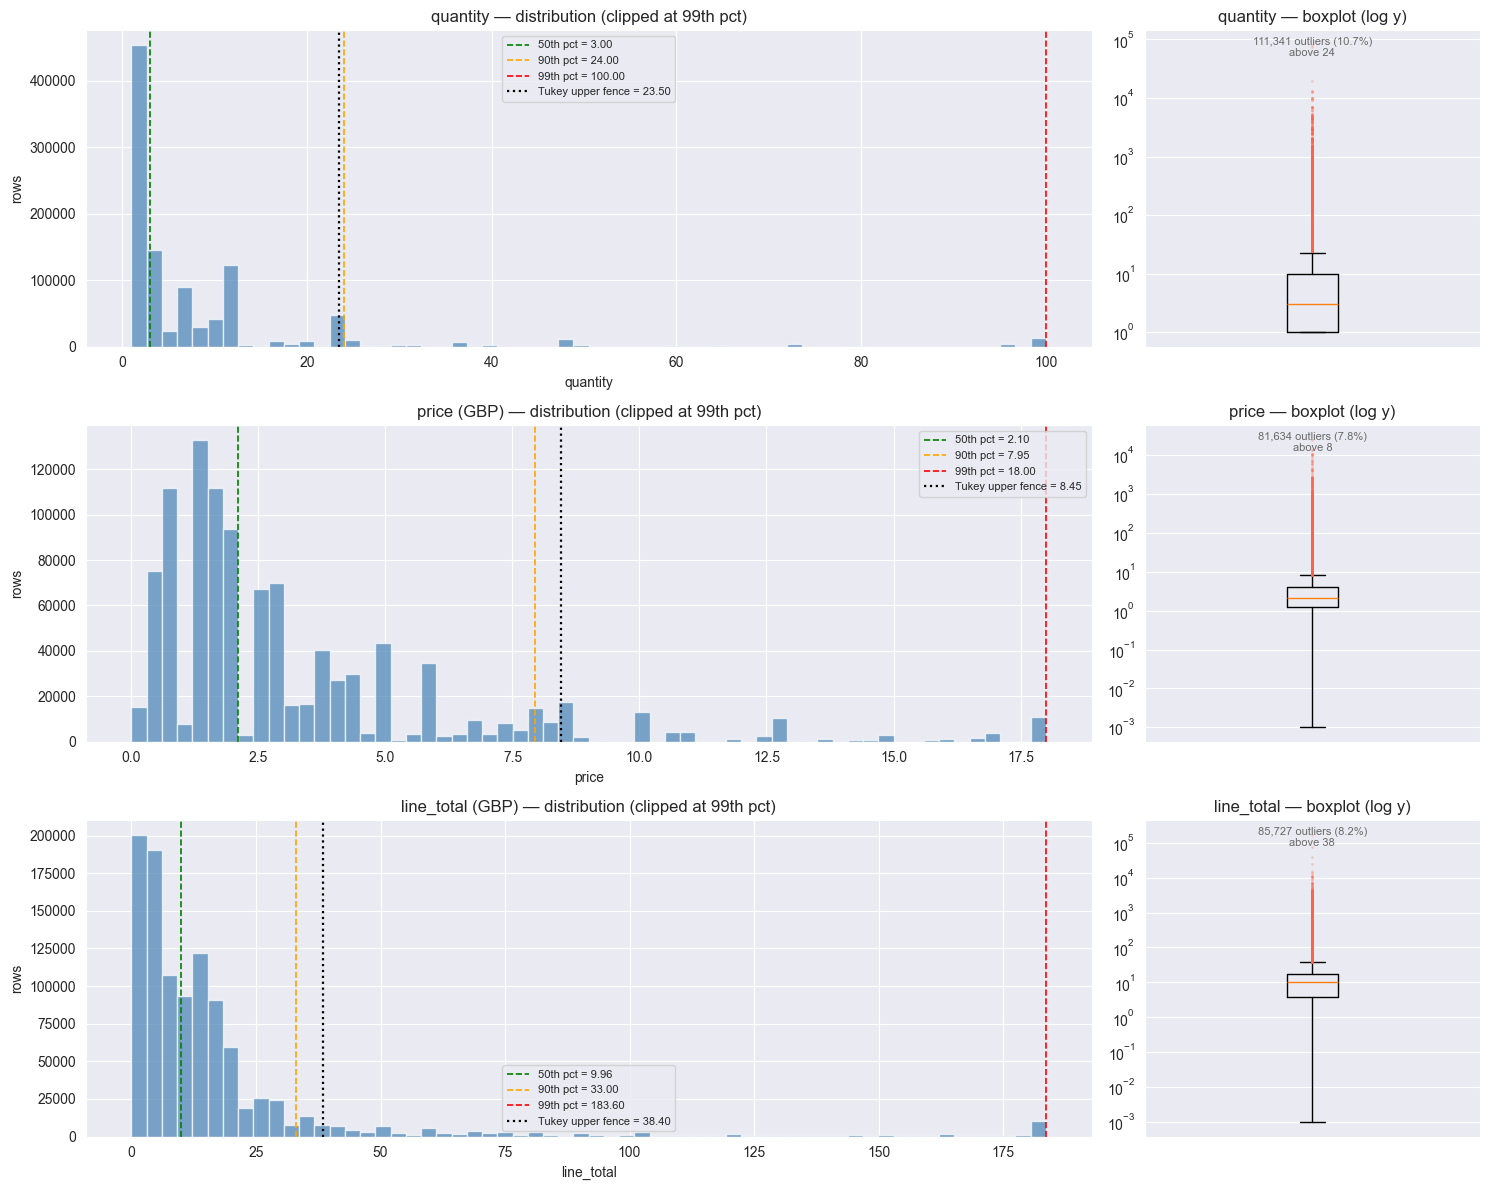

Summary (positive rows only):
          quantity        price   line_total
count 1,041,671.00 1,041,671.00 1,041,671.00
mean         10.96         4.08        20.13
std         126.51        51.45       203.12
min           1.00         0.00         0.00
25%           1.00         1.25         3.90
50%           3.00         2.10         9.96
75%          10.00         4.13        17.70
90%          24.00         7.95        33.00
99%         100.00        18.00       183.60
max      80,995.00    25,111.09   168,469.60


In [125]:
clean = df[(df['quantity'] > 0) & (df['price'] > 0)].copy()
clean['line_total'] = clean['quantity'] * clean['price']

cols  = ['quantity', 'price', 'line_total']
units = {'quantity': '', 'price': ' (GBP)', 'line_total': ' (GBP)'}
pct_marks = [(50, 'green'), (90, 'orange'), (99, 'red')]  # percentile lines on the histograms

fig, axes = plt.subplots(len(cols), 2, figsize=(15, 4 * len(cols)),
                         gridspec_kw={'width_ratios': [3, 1]})

for i, col in enumerate(cols):
    s = clean[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr            # Tukey rule (lower fence is < 0 here, so no low outliers)
    lower_fence = q1 - 1.5 * iqr
    is_out = (s < lower_fence) | (s > upper_fence)
    n_out, pct_out = is_out.sum(), is_out.mean() * 100
    clip = s.quantile(0.99)

    # --- left: histogram (clipped at 99th pct for readability) with percentile + fence lines
    ax_h = axes[i, 0]
    ax_h.hist(s.clip(upper=clip), bins=60, color='steelblue', alpha=0.7)
    for p, c in pct_marks:
        v = s.quantile(p / 100)
        if v <= clip:
            ax_h.axvline(v, color=c, ls='--', lw=1.2, label=f'{p}th pct = {v:,.2f}')
    if upper_fence <= clip:
        ax_h.axvline(upper_fence, color='black', ls=':', lw=1.6,
                     label=f'Tukey upper fence = {upper_fence:,.2f}')
    else:
        ax_h.plot([], [], color='black', ls=':', lw=1.6,
                  label=f'Tukey upper fence = {upper_fence:,.2f} (beyond view)')
    ax_h.set_title(f'{col}{units[col]} — distribution (clipped at 99th pct)')
    ax_h.set_xlabel(col)
    ax_h.set_ylabel('rows')
    ax_h.legend(fontsize=8)
    ax_h.ticklabel_format(style='plain', axis='both', useOffset=False)
    ax_h.yaxis.get_major_formatter().set_scientific(False)

    # --- right: boxplot (log scale; Tukey 1.5*IQR whiskers, outliers as points)
    ax_b = axes[i, 1]
    ax_b.boxplot(s, whis=1.5, showfliers=True,
                 flierprops=dict(marker='o', markersize=2, alpha=0.25, markerfacecolor='tomato',
                                 markeredgecolor='none'))
    ax_b.set_yscale('log')
    ax_b.set_title(f'{col} — boxplot (log y)')
    ax_b.set_xticks([])
    ax_b.annotate(f'{n_out:,} outliers ({pct_out:.1f}%)\nabove {upper_fence:,.0f}',
                  xy=(0.5, 0.98), xycoords='axes fraction', ha='center', va='top',
                  fontsize=8, color='dimgray')

plt.tight_layout()
plt.show()

print('Summary (positive rows only):')
print(clean[['quantity', 'price', 'line_total']]
      .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2))


## 7. Country Breakdown

In [113]:
country_rows      = df['country'].value_counts()
country_customers = df.groupby('country')['customer_id'].nunique()
country_revenue   = (clean.groupby('country')['line_total'].sum().sort_values(ascending=False))

top = pd.DataFrame({
    'rows': country_rows,
    'rows_pct': (country_rows / country_rows.sum() * 100).round(2),
    'unique_customers': country_customers,
    'revenue_gbp': country_revenue.round(0),
}).fillna(0).sort_values('rows', ascending=False).head(15)
top


,rows,rows_pct,unique_customers,revenue_gbp
country,,,,
United Kingdom,981330,91.94,5410,"17,871,351.00"
EIRE,17866,1.67,5,"664,432.00"
Germany,17624,1.65,107,"431,262.00"
France,14330,1.34,95,"356,945.00"
Netherlands,5140,0.48,23,"554,232.00"
Spain,3811,0.36,41,"109,179.00"
Switzerland,3189,0.30,22,"101,011.00"
Belgium,3123,0.29,29,"65,753.00"
Portugal,2620,0.25,24,"58,017.00"


## 8. Top Products

In [114]:
top_products = (
    clean.groupby(['stock_code', 'description'])
    .agg(units_sold=('quantity', 'sum'),
         n_customers=('customer_id', 'nunique'),
         n_invoices=('invoice', 'nunique'),
         revenue=('line_total', 'sum'))
    .sort_values('units_sold', ascending=False)
    .head(15)
    .reset_index()
)
print('Top 15 stock codes by units sold (with unique customer counts):')
top_products


Top 15 stock codes by units sold (with unique customer counts):


,stock_code,description,units_sold,n_customers,n_invoices,revenue
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,110138,482,1019,"25,259.90"
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96086,1490,5356,"262,931.16"
2,84879,ASSORTED COLOUR BIRD ORNAMENT,81809,1010,2807,"132,187.92"
3,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,1,1,"168,469.60"
4,85099B,JUMBO BAG RED RETROSPOT,78860,860,3245,"148,823.92"
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,138,247,"81,700.92"
6,17003,BROCADE RING PURSE,71430,215,456,"14,959.19"
7,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56794,767,1993,"28,490.98"
8,84991,60 TEATIME FAIRY CAKE CASES,54716,822,2127,"27,404.22"
9,22197,SMALL POPCORN HOLDER,49948,426,1407,"44,090.13"


## 9. Invoice-Level Aggregations

Each invoice contains multiple lines. Aggregate to one row per invoice and look at basket size and value. **All invoices are included** — cancellations and returns too — so a popular item that's constantly being returned still shows up here.


In [115]:
df['line_total'] = df['quantity'] * df['price']

invoice_agg = df.groupby('invoice').agg(
    n_lines=('stock_code', 'size'),
    n_unique_products=('stock_code', 'nunique'),
    total_quantity=('quantity', 'sum'),
    total_value=('line_total', 'sum'),
    invoice_date=('invoice_date', 'first'),
    customer_id=('customer_id', 'first'),
    country=('country', 'first'),
)
invoice_agg['is_cancellation'] = invoice_agg.index.astype(str).str.startswith('C')

print(f'Invoices : {len(invoice_agg):,}')
print(f'  Cancellation invoices : {invoice_agg["is_cancellation"].sum():,}')
print(f'  Regular invoices      : {(~invoice_agg["is_cancellation"]).sum():,}')
print()
print('Per-invoice summary (all invoices, includes returns):')
print(invoice_agg[['n_lines', 'n_unique_products', 'total_quantity', 'total_value']]
      .describe(percentiles=[0.5, 0.9, 0.99]).round(2))


Invoices : 53,628
  Cancellation invoices : 8,292
  Regular invoices      : 45,336

Per-invoice summary (all invoices, includes returns):
        n_lines  n_unique_products  total_quantity  total_value
count 53,628.00          53,628.00       53,628.00    53,628.00
mean      19.90              19.05          197.82       359.65
std       41.25              37.84        1,234.72     1,654.83
min        1.00               1.00      -87,167.00  -168,469.60
50%        9.00               9.00           93.00       196.34
90%       45.00              43.00          448.00       776.74
99%      177.00             172.00        1,992.00     3,840.18
max    1,350.00           1,110.00       87,167.00   168,469.60


## 10. Temporal Patterns

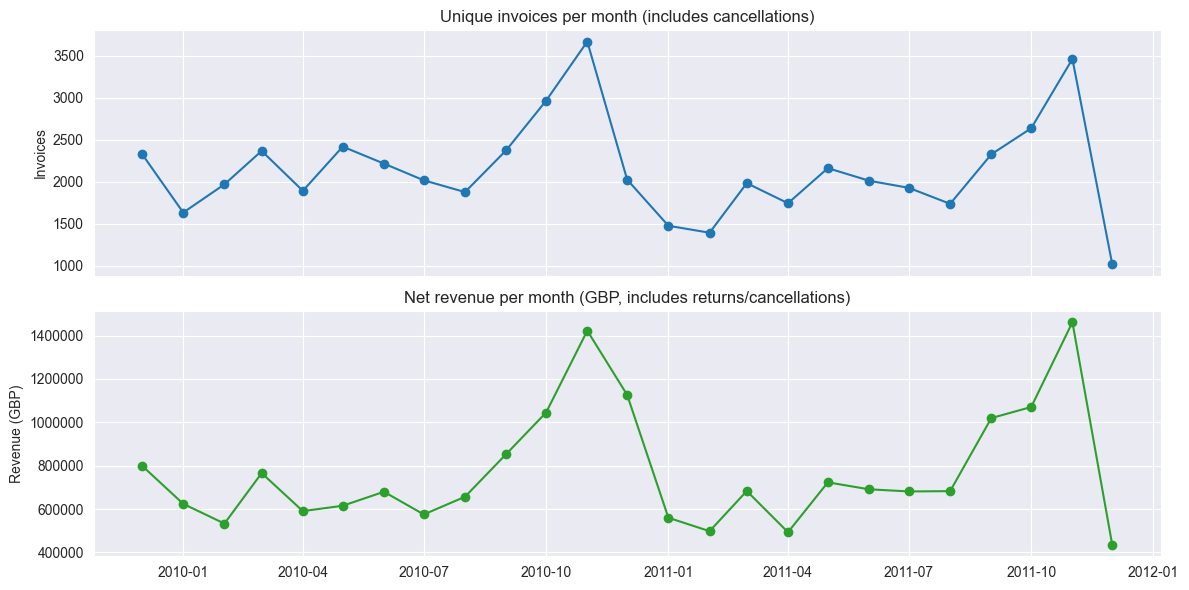

,transactions,revenue
month,,
2009-12-01,2330,"799,847.00"
2010-01-01,1633,"624,033.00"
2010-02-01,1969,"533,091.00"
2010-03-01,2367,"765,849.00"
2010-04-01,1892,"590,580.00"
2010-05-01,2418,"615,323.00"
2010-06-01,2216,"679,787.00"
2010-07-01,2017,"575,236.00"
2010-08-01,1877,"656,776.00"


In [116]:
df['line_total'] = df['quantity'] * df['price']

monthly = (df.assign(month=df['invoice_date'].dt.to_period('M'))
             .groupby('month')
             .agg(transactions=('invoice', 'nunique'),
                  revenue=('line_total', 'sum')))
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(monthly.index, monthly['transactions'], marker='o')
axes[0].set_title('Unique invoices per month (includes cancellations)')
axes[0].set_ylabel('Invoices')

axes[1].plot(monthly.index, monthly['revenue'], marker='o', color='tab:green')
axes[1].set_title('Net revenue per month (GBP, includes returns/cancellations)')
axes[1].set_ylabel('Revenue (GBP)')

for ax in axes:
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)
    ax.yaxis.get_major_formatter().set_scientific(False)

plt.tight_layout()
plt.show()

monthly.round(0)


## 11. Customer-Level Transaction Counts & Retention

For each attributed customer (excluding rows with missing `customer_id`), what is the percentage who reach an Nth purchase (N = 1..30), and what is the average/median gap in days between the (N-1)th and Nth purchase? A "purchase" here is a **unique invoice** ordered by date (cancellation invoices still count as transactions).


In [117]:
df['line_total'] = df['quantity'] * df['price']
attributed = df.dropna(subset=['customer_id']).copy()

per_customer = attributed.groupby('customer_id').agg(
    n_invoices=('invoice', 'nunique'),
    n_lines=('stock_code', 'size'),
    total_spend=('line_total', 'sum'),
    first_purchase=('invoice_date', 'min'),
    last_purchase=('invoice_date', 'max'),
)
per_customer['active_days'] = (per_customer['last_purchase'] - per_customer['first_purchase']).dt.days

total_customers = len(per_customer)
print(f'Attributed customers : {total_customers:,}')
print()
print('Per-customer summary:')
print(per_customer[['n_invoices', 'n_lines', 'total_spend', 'active_days']]
      .describe(percentiles=[0.5, 0.9, 0.99]).round(2))

invoice_seq = (attributed
               .groupby(['customer_id', 'invoice'])['invoice_date']
               .min()
               .reset_index()
               .sort_values(['customer_id', 'invoice_date']))
invoice_seq['purchase_rank'] = invoice_seq.groupby('customer_id').cumcount() + 1
invoice_seq['gap_days'] = (invoice_seq
                           .groupby('customer_id')['invoice_date']
                           .diff()
                           .dt.total_seconds() / 86400)

max_n = 30
rows = []
for n in range(1, max_n + 1):
    reached = (per_customer['n_invoices'] >= n).sum()
    pct = reached / total_customers * 100
    if n >= 2:
        gap_rows = invoice_seq.loc[invoice_seq['purchase_rank'] == n, 'gap_days']
        mean_gap = round(gap_rows.mean(), 2) if len(gap_rows) else None
        median_gap = round(gap_rows.median(), 2) if len(gap_rows) else None
        transition = f'{n-1} -> {n}'
    else:
        mean_gap = None
        median_gap = None
        transition = '—'
    rows.append({
        'nth_purchase': n,
        'transition': transition,
        'customers_reaching': reached,
        'pct_of_total': round(pct, 2),
        'mean_days': mean_gap,
        'median_days': median_gap,
    })

retention = pd.DataFrame(rows)
print()
print('Retention curve & inter-purchase gaps (Nth purchase, N = 1..30):')
retention


Attributed customers : 5,942

Per-customer summary:
       n_invoices   n_lines  total_spend  active_days
count    5,942.00  5,942.00     5,942.00     5,942.00
mean         7.55    138.74     2,801.80       275.40
std         15.97    359.69    13,973.92       259.69
min          1.00      1.00   -25,111.09         0.00
50%          4.00     53.00       843.97       225.00
90%         17.00    322.90     5,257.36       672.00
99%         56.59  1,130.36    26,484.14       733.00
max        510.00 13,097.00   598,215.22       738.00

Retention curve & inter-purchase gaps (Nth purchase, N = 1..30):


,nth_purchase,transition,customers_reaching,pct_of_total,mean_days,median_days
0,1,—,5942,100.00,NaN,NaN
1,2,1 -> 2,4481,75.41,79.12,36.11
2,3,2 -> 3,3606,60.69,71.92,34.89
3,4,3 -> 4,2984,50.22,61.51,28.86
4,5,4 -> 5,2502,42.11,59.25,29.06
5,6,5 -> 6,2112,35.54,47.55,24.14
6,7,6 -> 7,1831,30.81,48.90,25.98
7,8,7 -> 8,1577,26.54,44.62,21.01
8,9,8 -> 9,1400,23.56,40.57,20.99
9,10,9 -> 10,1242,20.90,38.16,20.97


In [118]:
# Churn definition: a customer is "churn" if they do NOT make a 2nd purchase
# within N days of their 1st purchase. Customers whose 1st purchase is within
# the last N days of the dataset are excluded (right-censored — they have not
# had a full N-day window in which a 2nd purchase could occur).
dataset_end = df['invoice_date'].max()

first_purchase  = invoice_seq.loc[invoice_seq['purchase_rank'] == 1].set_index('customer_id')['invoice_date']
second_purchase = invoice_seq.loc[invoice_seq['purchase_rank'] == 2].set_index('customer_id')['invoice_date']

customer_purchases = pd.DataFrame({'first': first_purchase, 'second': second_purchase})
customer_purchases['days_to_second'] = (
    (customer_purchases['second'] - customer_purchases['first']).dt.total_seconds() / 86400
)

rows = []
for thresh in [30, 60, 90]:
    cutoff = dataset_end - pd.Timedelta(days=thresh)
    eligible = customer_purchases[customer_purchases['first'] <= cutoff]
    excluded = len(customer_purchases) - len(eligible)

    has_second_in_window = (eligible['days_to_second'] <= thresh).fillna(False)
    churned = (~has_second_in_window).sum()
    non_churned = has_second_in_window.sum()
    pct_churn = churned / len(eligible) * 100

    rows.append({
        'threshold_days': thresh,
        'eligible_customers': len(eligible),
        'excluded_right_censored': excluded,
        'churned': churned,
        'non_churned': non_churned,
        'pct_churned': round(pct_churn, 2),
        'pct_non_churned': round(100 - pct_churn, 2),
    })

churn_by_threshold = pd.DataFrame(rows)
print(f'Dataset end                : {dataset_end}')
print(f'Total attributed customers : {total_customers:,}')
print()
print('Churn % by 1st → 2nd-purchase window (churn = no 2nd purchase within N days of 1st):')
churn_by_threshold


Dataset end                : 2011-12-09 12:50:00
Total attributed customers : 5,942

Churn % by 1st → 2nd-purchase window (churn = no 2nd purchase within N days of 1st):


,threshold_days,eligible_customers,excluded_right_censored,churned,non_churned,pct_churned,pct_non_churned
0,30,5780,162,3775,2005,65.31,34.69
1,60,5581,361,2953,2628,52.91,47.09
2,90,5346,596,2433,2913,45.51,54.49


## 12. Inter-Purchase Gaps

For each customer with ≥ 2 invoices, days between consecutive invoices. Complementary view to the per-transition table in section 11 — shows the overall shape of the gap distribution.


Customers with ≥ 2 invoices : 4,481
Inter-invoice gap observations: 38,934

count   38,934.00
mean        42.09
std         69.96
min          0.00
50%         15.28
75%         48.04
90%        114.57
95%        180.97
99%        356.04
max        701.13
Name: gap_days, dtype: float64


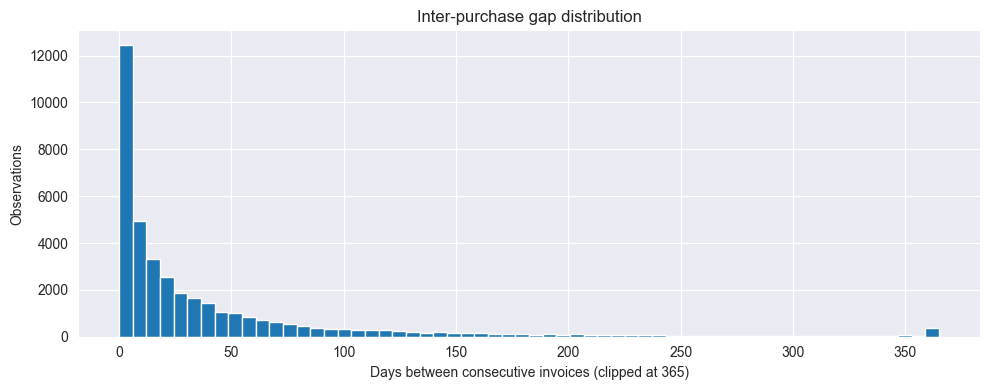

In [119]:
invoice_dates = (attributed
                 .groupby(['customer_id', 'invoice'])['invoice_date']
                 .min()
                 .reset_index()
                 .sort_values(['customer_id', 'invoice_date']))

invoice_dates['gap_days'] = (invoice_dates
                             .groupby('customer_id')['invoice_date']
                             .diff()
                             .dt.total_seconds() / 86400)

gaps = invoice_dates['gap_days'].dropna()
print(f'Customers with ≥ 2 invoices : {(per_customer["n_invoices"] >= 2).sum():,}')
print(f'Inter-invoice gap observations: {len(gaps):,}')
print()
print(gaps.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gaps.clip(upper=365), bins=60)
ax.set_xlabel('Days between consecutive invoices (clipped at 365)')
ax.set_ylabel('Observations')
ax.set_title('Inter-purchase gap distribution')
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.get_major_formatter().set_scientific(False)
plt.tight_layout()
plt.show()


Based on the analysis, I am going to predict if the customer will make another purchase after the 1st purchase. <br> More specifically, if a customer made a 2nd purchase within 90 days after the 1st purchase, then the customer will be assigned 0 for churn. <br> If a customer did not make a purchase after the 1st one, or if the customer made the 2nd purchase after 90 days from the 1st purchase, then the customer will be assigned 1 for churn. <br> This labelled first-transaction dataset is produced by `data/processing/prepare_churn_data.py`.

## Data Quality Issues to Address

The EDA surfaced the following issues that need to be addressed:

1. Missing values for the `customer_id` and `description` variables.
2. For some products, `price = 0`.
3. For one stock code we have more than one description.
4. For the exact same description, we have more than one `stock_code`.
5. Some stock codes consist of letters only (most are numbers only, or numbers + letters).
6. Some stock codes are followed by letters.
7. Some stock codes do not make much sense (e.g., `gift_0001_80`).
8. Invoices that start with `C` (cancellations).
9. Outlier values in the continuous variables.

Since I am taking only the 1st transaction and trying to predict if the customer is going to churn in the next 90-days, I will filter to the 1st transaction only and then address the data issues identified as some of those may be fixed after taking the 1st transaction only.
